# Milestone 1: Week 3 - Forward and Backward Selection, Principal Component Regression, Partial Least Squares Regression

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
random_seed = 42

#### Forward Selection

In [3]:
cdc_cancer_mortalities = pd.read_csv('..\..\Milestone 3\Processed Data\cdc_cancer_deaths_encoded.csv')
cdc_cancer_mortalities.head()

,AGE,CAUSE_RECODE_113,DATA_YEAR,EDUCATION_CODED,HISPANIC_CODED,MANNER_OF_DEATH_CODED,MONTH_OF_DEATH,PLACE_OF_DEATH_CODED,RESIDENT_STATUS_CODED,WEEKDAY_OF_DEATH,...,PLACE_OF_DEATH_Hospital (Dead on Arrival),PLACE_OF_DEATH_Hospital (Inpatient),PLACE_OF_DEATH_Hospital (Outpatient/ER),PLACE_OF_DEATH_Nursing home,PLACE_OF_DEATH_Other,PLACE_OF_DEATH_Unknown,AUTOPSY_N,AUTOPSY_U,AUTOPSY_Y,AUTOPSY_n
0,93.0,33,2018,61,6,7.0,1,6,1,3,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,61.0,23,2018,51,6,7.0,1,4,1,4,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,63.0,25,2018,41,6,7.0,1,4,1,5,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,67.0,27,2018,31,6,7.0,1,4,1,6,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,76.0,27,2018,31,6,7.0,1,4,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [4]:
X = cdc_cancer_mortalities.drop(columns=['AGE']).copy()
y = cdc_cancer_mortalities['AGE'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_seed)

In [14]:
# Code adapted from Professor Joshua Von Korff's foward selection notes

def forward_selection(X, y, max_features=10):
    remaining = list(X.columns)
    selected = []
    history = []

    for step in range(max_features):
        best_feature = None
        best_score = np.inf

        for feature in remaining:
            candidate_features = selected + [feature]
            model = LinearRegression()
            scores = cross_val_score(
                model,
                X[candidate_features],
                y,
                cv=5,
                scoring="neg_root_mean_squared_error"
            )
            rmse = -scores.mean()

            if rmse < best_score:
                best_score = rmse
                best_feature = feature

        selected.append(best_feature)
        remaining.remove(best_feature)
        history.append((step + 1, best_feature, best_score))

    return selected, history

selected_features, history = forward_selection(X_train, y_train, max_features=10)

print("Forward selection order:")
for step, feature, score in history:
    print(f"Step {step}: add {feature:>3s} | CV RMSE = {score:.4f}")

print("\nFinal selected order:")
print(selected_features)

# ------------------------------------------------------------
# 2) Compare model size vs performance
# ------------------------------------------------------------
print("\nCV RMSE by number of selected features:")
for k in range(1, 11):
    feats = selected_features[:k]
    model = LinearRegression()
    scores = cross_val_score(
        model,
        X[feats],
        y,
        cv=5,
        scoring="neg_root_mean_squared_error"
    )
    rmse = -scores.mean()
    print(f"{k} features: {rmse} years")

Forward selection order:
Step 1: add MARITAL_STATUS_Widowed | CV RMSE = 11.8744
Step 2: add MARITAL_STATUS_Never Married | CV RMSE = 11.6085
Step 3: add CAUSE_OF_DEATH_Malignant neoplasm of prostate (C61) | CV RMSE = 11.4759
Step 4: add PLACE_OF_DEATH_CODED | CV RMSE = 11.3575
Step 5: add CAUSE_OF_DEATH_Malignant neoplasms of meninges, brain and other parts of central nervous system (C70-C72) | CV RMSE = 11.2989
Step 6: add RACE_White | CV RMSE = 11.2434
Step 7: add PLACE_OF_DEATH_Nursing home | CV RMSE = 11.2013
Step 8: add CAUSE_OF_DEATH_Malignant neoplasm of cervix uteri (C53) | CV RMSE = 11.1638
Step 9: add CAUSE_OF_DEATH_Malignant neoplasm of bladder (C67) | CV RMSE = 11.1279
Step 10: add RESIDENT_STATUS_Resident | CV RMSE = 11.1008

Final selected order:
['MARITAL_STATUS_Widowed', 'MARITAL_STATUS_Never Married', 'CAUSE_OF_DEATH_Malignant neoplasm of prostate (C61)', 'PLACE_OF_DEATH_CODED', 'CAUSE_OF_DEATH_Malignant neoplasms of meninges, brain and other parts of central nervous s

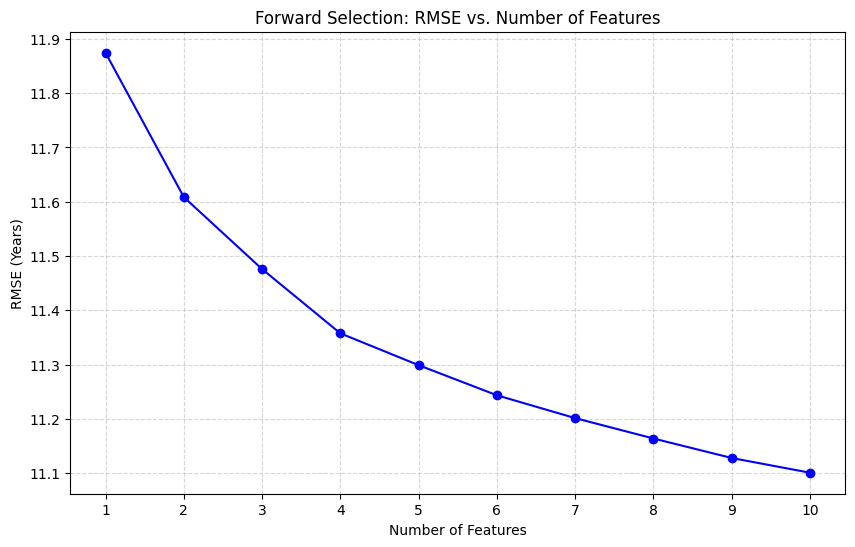

In [15]:
steps = [i[0] for i in history]
rmse_values = [i[2] for i in history]

plt.figure(figsize=(10,6))
plt.plot(steps, rmse_values, marker='o', color='b')
plt.title("Forward Selection: RMSE vs. Number of Features")
plt.xlabel("Number of Features")
plt.ylabel("RMSE (Years)")
plt.xticks(steps)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Interpretation:

There really wasn't a significant improvement from 1 to 10 features in terms of the root mean squared error in years. This means that the model was quickly able to capture impactful predictive power and then the other features did not significantly improve the prediction of people's age of death from cancer. If I were to create a more comprehensive model, I could look at the graph above and determine what is considered the most significant cutoff point for most predictive power before the RMSE improvement is too minimal. 

#### Backward Selection

In [48]:
cancer_rates = pd.read_csv(r"..\..\Milestone 3\Processed Data\NCI Cancer Rates.csv")
cancer_rates.head()

,State,County,FIPS,2023 Rural-Urban Continuum Codes([rural urban note]),Sex,Race,"Age-Adjusted Incidence Rate([rate note]) - cases per 100,000",Lower 95% Confidence Interval,Upper 95% Confidence Interval,CI*Rank([rank note]),Lower CI (CI*Rank),Upper CI (CI*Rank),Average Annual Count,Recent Trend,Recent 5-Year Trend ([trend note]) in Incidence Rates,Lower 95% Confidence Interval.1,Upper 95% Confidence Interval.1
0,NaN,US (SEER+NPCR)(1),0,NaN,Female,Asian,308.9,307.4,310.3,NaN,NaN,NaN,37611,-8888.0,0.5,0.4,0.6
1,Oklahoma,Wagoner,40145,Urban,Female,Asian,760.8,421.4,1233.8,NaN,NaN,NaN,4,-9999.0,-9999.0,-9999.0,-9999.0
2,Montana,Cascade,30013,Urban,Female,Asian,646.9,392.2,1006.2,NaN,NaN,NaN,5,-9999.0,-9999.0,-9999.0,-9999.0
3,California,Tuolumne,6109,Rural,Female,Asian,616.2,261.8,1185.3,NaN,NaN,NaN,4,-9999.0,-9999.0,-9999.0,-9999.0
4,North Carolina,Hoke,37093,Urban,Female,Asian,586.3,320.2,982.9,NaN,NaN,NaN,3,-9999.0,-9999.0,-9999.0,-9999.0


In [49]:
numeric_cols = cancer_rates.select_dtypes(include=['number']).columns

flag_map = {
    '*': -9999,
    '[P1 note]': -9998,
    '[P3 note]': -9997,
    '[S3 note]': -9996,
    '&para': -9995,

    'rising': -8888,
    'falling': -8887,
    'stable': -8886,
}

flag_vals = flag_map.values()

cols = ['Age-Adjusted Incidence Rate([rate note]) - cases per 100,000', 'Lower 95% Confidence Interval', 'Upper 95% Confidence Interval', 'CI*Rank([rank note])',
        'Lower CI (CI*Rank)', 'Upper CI (CI*Rank)', 'Average Annual Count', 'Recent Trend', 'Recent 5-Year Trend ([trend note]) in Incidence Rates', 'Lower 95% Confidence Interval.1', 'Upper 95% Confidence Interval.1']

print('==================== TOTAL FLAG PERCENTAGE PER FEATURE ====================\n\n')
for col in cols:
    if col in cancer_rates.columns:
        print(f"--- Frequencies for {col} ---")
        # value_counts(normalize=True) gives the percentage (0.0 to 1.0)
        # We look specifically for the keys in your flag_map
        counts = cancer_rates[col].value_counts(normalize=True, dropna=False)
        
        for name, value in flag_map.items():
            if value in counts.index:
                pct = counts[value]
                print(f"Flag: {name:<10} | Value: {value} | Percentage: {pct:.2%}")
        print("\n")

==================== TOTAL FLAG PERCENTAGE PER FEATURE ====================


--- Frequencies for Age-Adjusted Incidence Rate([rate note]) - cases per 100,000 ---


--- Frequencies for Lower 95% Confidence Interval ---
Flag: *          | Value: -9999 | Percentage: 56.32%
Flag: [P1 note]  | Value: -9998 | Percentage: 3.34%
Flag: [P3 note]  | Value: -9997 | Percentage: 0.03%
Flag: [S3 note]  | Value: -9996 | Percentage: 1.18%


--- Frequencies for Upper 95% Confidence Interval ---


--- Frequencies for CI*Rank([rank note]) ---


--- Frequencies for Lower CI (CI*Rank) ---


--- Frequencies for Upper CI (CI*Rank) ---


--- Frequencies for Average Annual Count ---
Flag: [P1 note]  | Value: -9998 | Percentage: 3.34%
Flag: [P3 note]  | Value: -9997 | Percentage: 0.03%
Flag: [S3 note]  | Value: -9996 | Percentage: 1.18%


--- Frequencies for Recent Trend ---
Flag: *          | Value: -9999 | Percentage: 61.36%
Flag: [P1 note]  | Value: -9998 | Percentage: 3.34%
Flag: [P3 note]  | Value: -9997 

For now, I will not do backwards selection on this dataset because I would need to impute this dataset due to the missing values. But, because there is a high percentage of flagged values, I would need to somehow do the imputing based solely on the actual values and not the flagged ones since those values are more categorical than numerical.

In [54]:
life_expect_nchs = pd.read_csv(r"..\..\Milestone 3\Processed Data\nchs_life_expect_encoded.csv")
life_expect_nchs.head()

,Age-adjusted Death Rate,Average Life Expectancy (Years),Year,Race_Black,Race_White,Sex_Female,Sex_Male
0,2518.0,47.3,1900,False,False,False,False
1,2473.1,49.1,1901,False,False,False,False
2,2301.3,51.5,1902,False,False,False,False
3,2379.0,50.5,1903,False,False,False,False
4,2502.5,47.6,1904,False,False,False,False


In [68]:
bool_cols = life_expect_nchs.select_dtypes(include=['bool']).columns
life_expect_nchs[bool_cols] = life_expect_nchs[bool_cols].astype(int)
life_expect_nchs.head()

,Age-adjusted Death Rate,Average Life Expectancy (Years),Year,Race_Black,Race_White,Sex_Female,Sex_Male
0,2518,47.3,1900,0,0,0,0
1,2473,49.1,1901,0,0,0,0
2,2301,51.5,1902,0,0,0,0
3,2379,50.5,1903,0,0,0,0
4,2502,47.6,1904,0,0,0,0


In [69]:
life_expect_nchs = life_expect_nchs.to_csv(r"..\..\Milestone 3\Processed Data\nchs_life_expect_encoded.csv", index=False)

In [70]:
life_expect_nchs = pd.read_csv(r"..\..\Milestone 3\Processed Data\nchs_life_expect_encoded.csv")
life_expect_nchs.head()

,Age-adjusted Death Rate,Average Life Expectancy (Years),Year,Race_Black,Race_White,Sex_Female,Sex_Male
0,2518,47.3,1900,0,0,0,0
1,2473,49.1,1901,0,0,0,0
2,2301,51.5,1902,0,0,0,0
3,2379,50.5,1903,0,0,0,0
4,2502,47.6,1904,0,0,0,0


In [ ]:
na_rows = life_expect_nchs.isna().any(axis=1)
print(f"Total rows: {len(life_expect_nchs)} | NA rows: {len(life_expect_nchs[na_rows])}")

life_expect_nchs[na_rows]

Total rows: 1071 | NA rows: 6


,Age-adjusted Death Rate,Average Life Expectancy (Years),Year,Race_Black,Race_White,Sex_Female,Sex_Male
475,852,NaN,2018,1,0,0,0
594,702,NaN,2018,1,0,1,0
713,1051,NaN,2018,1,0,0,1
832,725,NaN,2018,0,1,0,0
951,614,NaN,2018,0,1,1,0
1070,853,NaN,2018,0,1,0,1


In [75]:
# dropping since only 6 rows
life_expect_nchs = life_expect_nchs[~na_rows]

In [88]:
X = life_expect_nchs.drop(columns=['Average Life Expectancy (Years)'])
y = life_expect_nchs['Average Life Expectancy (Years)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_seed)

In [89]:
# Code adapted from Professor Joshua Von Korff's backward selection notes

def cv_rmse(X, y, features):
    model = LinearRegression()
    scores = cross_val_score(
        model,
        X[features],
        y,
        cv=5,
        scoring="neg_root_mean_squared_error"
    )
    return -scores.mean()

def backward_selection(X, y, min_features=1):
    selected = list(X.columns)
    history = []

    while len(selected) > min_features:
        best_score = np.inf
        best_candidate = None
        feature_removed = None

        for feature in selected:
            candidate = [f for f in selected if f != feature]
            mse = cv_rmse(X, y, candidate)

            if mse < best_score:
                best_score = mse
                best_candidate = candidate
                feature_removed = feature

        selected = best_candidate
        history.append((feature_removed, selected.copy(), best_score))

    return selected, history

selected_features, history = backward_selection(X_train, y_train, min_features=1)

print("Backward selection path:")
print(f"Start with all 10 features | CV RMSE = {cv_rmse(X, y, list(X.columns)):.4f}")
for removed_feature, remaining_features, score in history:
    print(f"Remove {removed_feature:>3s} -> keep {remaining_features} | CV RMSE = {score:.4f}")

print("\nFinal selected feature(s):", selected_features)

Backward selection path:
Start with all 10 features | CV RMSE = 1.6856
Remove Year -> keep ['Age-adjusted Death Rate', 'Race_Black', 'Race_White', 'Sex_Female', 'Sex_Male'] | CV RMSE = 1.6325
Remove Race_White -> keep ['Age-adjusted Death Rate', 'Race_Black', 'Sex_Female', 'Sex_Male'] | CV RMSE = 1.6358
Remove Sex_Female -> keep ['Age-adjusted Death Rate', 'Race_Black', 'Sex_Male'] | CV RMSE = 1.6416
Remove Sex_Male -> keep ['Age-adjusted Death Rate', 'Race_Black'] | CV RMSE = 1.7378
Remove Race_Black -> keep ['Age-adjusted Death Rate'] | CV RMSE = 1.8557

Final selected feature(s): ['Age-adjusted Death Rate']


Interesting enough, the backwards selection algorithm selected only `Age-adjusted Death Rate` with an RMSE of 1.8557 years. However, this is not the best selection because when you look back at the steps it was actually ['Age-adjusted Death Rate', 'Race_Black', 'Race_White', 'Sex_Female', 'Sex_Male'] with an RMSE of 1.6325 years. This is because the algoritm continues until it reaches the minimum features, rather than waiting for the lowest RMSE before stopping once the RMSE gets worse. I will try this again with sklearn's backwards selection model.

In [3]:
from sklearn.feature_selection import SequentialFeatureSelector

In [96]:
backwards_fs = SequentialFeatureSelector(LinearRegression(), n_features_to_select='auto', direction='backward', scoring='neg_root_mean_squared_error', cv=5)
backwards_fs.fit(X_train, y_train)
selected_features = X_train.columns[backwards_fs.get_support()].tolist()
print(f"Selected features: {selected_features} | RMSE: {cv_rmse(X_train, y_train, selected_features)}")

Selected features: ['Age-adjusted Death Rate', 'Race_Black', 'Sex_Male'] | RMSE: 1.6415692846146996


sklearn's SequentialFeatureSelector resulted in a better RMSE score to predict the average life expectancy at birth compared to the manual algorithm.

#### Principal Component Regression (PCR)

In [3]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [4]:
cancer_deaths = pd.read_csv("..\Processed Data\cdc_cancer_deaths_encoded.csv")
cancer_deaths.head()

,AGE,CAUSE_RECODE_113,DATA_YEAR,EDUCATION_CODED,HISPANIC_CODED,MANNER_OF_DEATH_CODED,MONTH_OF_DEATH,PLACE_OF_DEATH_CODED,RESIDENT_STATUS_CODED,WEEKDAY_OF_DEATH,...,PLACE_OF_DEATH_Hospital (Dead on Arrival),PLACE_OF_DEATH_Hospital (Inpatient),PLACE_OF_DEATH_Hospital (Outpatient/ER),PLACE_OF_DEATH_Nursing home,PLACE_OF_DEATH_Other,PLACE_OF_DEATH_Unknown,AUTOPSY_N,AUTOPSY_U,AUTOPSY_Y,AUTOPSY_n
0,93.0,33,2018,61,6,7.0,1,6,1,3,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,61.0,23,2018,51,6,7.0,1,4,1,4,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,63.0,25,2018,41,6,7.0,1,4,1,5,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,67.0,27,2018,31,6,7.0,1,4,1,6,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,76.0,27,2018,31,6,7.0,1,4,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [5]:
X = cancer_deaths.drop(columns=['AGE'])
y = cancer_deaths['AGE']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_seed)

In [ ]:
pcr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('regressor', LinearRegression())
])

pcr_pipeline.fit(X_train, y_train)
y_pred = pcr_pipeline.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"===== PCR Model =====\n")
print(f"MSE: {mse} years")
print(f"RMSE: {rmse} years")
print(f"Number of components kept: {pcr_pipeline.named_steps['pca'].n_components_}")
print(f"Number of components dropped: {len(X.columns.tolist()) - pcr_pipeline.named_steps['pca'].n_components_}")

===== PCR Model =====

MSE: 121.52914591547257 years
RMSE: 11.024025848820955 years
Number of components kept: 82
Number of components dropped: 27


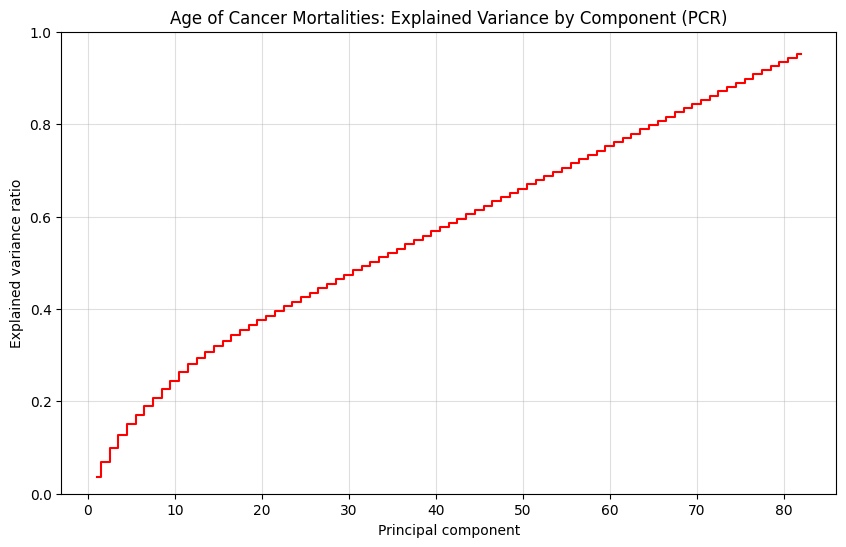

In [37]:
pca = pcr_pipeline.named_steps['pca']
var_ratio = pcr_pipeline.named_steps['pca'].explained_variance_ratio_

plt.figure(figsize=(10, 6))
plt.step(range(1, len(var_ratio) + 1), np.cumsum(var_ratio), where='mid', color='red')

plt.ylim(0, 1)

plt.xlabel('Principal component')
plt.ylabel('Explained variance ratio')
plt.title("Age of Cancer Mortalities: Explained Variance by Component (PCR)")
plt.grid(True, alpha=0.4)
plt.show()

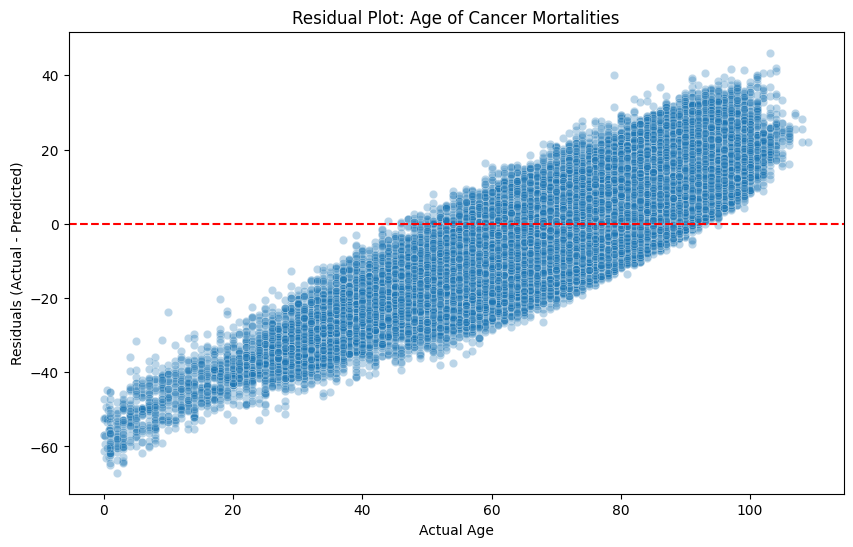

In [40]:
residuals = y_test - y_pred
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Actual Age')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot: Age of Cancer Mortalities')
plt.show()

The predictions on the lower range for age are significantly higher since the residuals are into the negative. In contrast, the higher end face lower age predictions. In a perfect scenario, everything would be plotted on the red dotted line but that would also be a clear overfitting example. However, it is still important to note the shortcomings of this PCR model.

#### Partial Least Squares Regression (PLSR)

In [6]:
from sklearn.cross_decomposition import PLSRegression

In [9]:
plsr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('plsr', PLSRegression(n_components=5))
])

plsr_pipeline.fit(X_train, y_train)

y_pred_plsr = plsr_pipeline.predict(X_test)
mse_plsr = mean_squared_error(y_test, y_pred_plsr)
rmse_plsr = np.sqrt(mse_plsr)

print(f"===== PLSR Model =====\n")
print(f"MSE: {mse_plsr} years")
print(f"RMSE: {rmse_plsr} years")
print(f"Number of components kept: {plsr_pipeline.named_steps['plsr'].n_components}")
print(f"Number of components dropped: {len(X.columns.tolist()) - plsr_pipeline.named_steps['plsr'].n_components}")

===== PLSR Model =====

MSE: 120.35559932409983 years
RMSE: 10.970669957851245 years
Number of components kept: 5
Number of components dropped: 104


Interpretation:
The PLSR model massively reduced the complexity of the dimensionality by keeping just 5 components that maximized the most covariance between the projected features and `AGE`. This model has a significant reduction in complexity compared to the PCR model (5 vs 82 components) while maintaining a slightly lower RMSE of 10.97 years vs 11.02.

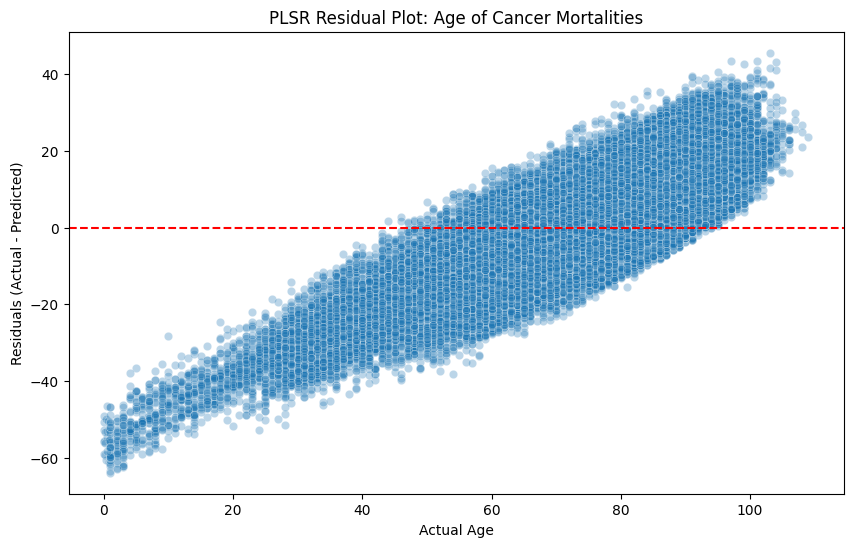

In [10]:
residuals = y_test - y_pred_plsr
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Actual Age')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('PLSR Residual Plot: Age of Cancer Mortalities')
plt.show()

Both residual plots look virtually the same meaning that there is no real bias between the two models in terms of the residuals. While there was a slight improvement in RMSE for the PLSR model, the residual plots show that structurally the improvements were not that significant. This may be because there is not a linear nature for this model and we must consider a different model in the pipeline to capture a better non-linear prediction.